In [17]:
import pandas as pd
import numpy as np

In [39]:
data = pd.read_csv("gs://ukbb_spleen/CHIPCAD_pheno_v5.csv", sep='\s+')
data.head()

,ID,Filename,age,race,Sex,SmokingStatusv2,tchol,hdl,SBP,antihtnbase,...,DNMT3A_10,non_DNMT3A_10,TET2_10,ASXL1_10,JAK2_10,PPM1D_10,TP53_10,SF3B1_10,SRSF2_10,statin0
0,1000107,1000107_20201_2_0.zip,49,white,Female,Previous,199.845320,61.059551,153.0,0,...,0,0,0,0,0,0,0,0,0,0
1,1000169,1000169_20201_2_0.zip,59,white,Female,Previous,239.211135,55.220417,130.0,0,...,0,0,0,0,0,0,0,0,0,0
2,1000336,1000336_20201_2_0.zip,42,white,Female,Current,203.750965,70.843000,118.0,0,...,0,0,0,0,0,0,0,0,0,0
3,1000387,1000387_20201_2_0.zip,64,white,Female,Never,268.174786,72.351121,153.0,0,...,0,0,0,0,0,0,0,0,0,0
4,1000408,1000408_20201_2_0.zip,56,white,Female,Never,242.459395,54.911059,113.0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
data.statin0.value_counts(dropna=False)
data.columns

Index(['ID', 'Filename', 'age', 'race', 'Sex', 'SmokingStatusv2', 'tchol',
       'hdl', 'SBP', 'antihtnbase', 'dm2_prev', 'dm1_prev', 'pce_goff',
       'genotyping_array', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7',
       'PC8', 'PC9', 'PC10', 'Coronary_Artery_Disease',
       'Prev_Coronary_Artery_Disease', 'Incd_Coronary_Artery_Disease',
       'FollowUp_Coronary_Artery_Disease', 'Coronary_Artery_Disease_HARD',
       'Prev_Coronary_Artery_Disease_HARD',
       'Incd_Coronary_Artery_Disease_HARD',
       'FollowUp_Coronary_Artery_Disease_HARD',
       'Coronary_Artery_Disease_INTERMEDIATE',
       'Prev_Coronary_Artery_Disease_INTERMEDIATE',
       'Incd_Coronary_Artery_Disease_INTERMEDIATE',
       'FollowUp_Coronary_Artery_Disease_INTERMEDIATE',
       'Coronary_Artery_Disease_SOFT', 'Prev_Coronary_Artery_Disease_SOFT',
       'Incd_Coronary_Artery_Disease_SOFT',
       'FollowUp_Coronary_Artery_Disease_SOFT', 'composite_mi_cad_stroke',
       'Prev_composite_mi_cad_stroke'

In [75]:
mri_data = pd.read_csv("gs://ukbb_spleen/MRI_acquisition_times.csv", sep=',')
mri_data = mri_data.rename({'Unnamed: 0': 'ID', 'sex': 'Sex', 'enroll_age':'age'}, axis='columns')
mri_data.acquisition_time = pd.DatetimeIndex(mri_data.acquisition_time).normalize()
mri_data.enroll_date = pd.DatetimeIndex(mri_data.enroll_date).normalize()

mri_data['time_to_mri_acquisition'] = (mri_data['acquisition_time']  - mri_data['enroll_date'] ).astype('timedelta64[D]').astype('int64')

mri_data['manual_age_at_mri'] = mri_data['age'] + (mri_data['acquisition_time']  - mri_data['enroll_date'] ).astype('timedelta64[D]').astype('int64')/365.25
mri_data['age'] = mri_data['age'].apply(np.floor).astype(int)
mri_data.head()

,ID,files,Sex,enroll_date,age,birthdate,acquisition_time,age_at_mri,predicted_age,time_to_mri_acquisition,manual_age_at_mri
0,1000107,/mnt/disks/mdrk-reingest-10tb/ukb_bulk/liver/i...,Female,2009-02-05,49,1959-11-15,2017-07-18,57.674011,52.849648,3085,57.668492
1,1000336,/mnt/disks/mdrk-reingest-10tb/ukb_bulk/liver/i...,Female,2008-08-19,42,1966-04-15,2019-10-19,53.512392,55.308680,4078,53.509400
2,1000387,/mnt/disks/mdrk-reingest-10tb/ukb_bulk/liver/i...,Female,2009-12-11,64,1945-01-15,2018-01-12,72.992601,76.734820,2954,72.995944
3,1000408,/mnt/disks/mdrk-reingest-10tb/ukb_bulk/liver/i...,Female,2008-07-19,56,1951-09-15,2019-12-01,68.212215,65.637375,4152,68.212000
4,1000426,/mnt/disks/mdrk-reingest-10tb/ukb_bulk/liver/i...,Female,2010-05-10,61,1948-05-15,2018-05-21,70.016496,64.323090,2933,70.019005


In [98]:
# make sure that the IDs match up
data.drop_duplicates('ID', inplace = True)
print(data.shape)
print(len(data.ID.unique()))

print(mri_data.shape)
print(len(mri_data.ID.unique()))

mri_data = mri_data[['ID', 'Sex', 'age', 'time_to_mri_acquisition', 'manual_age_at_mri']]

merged = data.merge(mri_data, on = ['ID', 'age', 'Sex'], how = 'inner')
print(merged.shape)
print(len(merged.ID.unique()))
print(merged.columns)
merged.head()

(43543, 73)
43543
(30183, 5)
30183
(29150, 75)
29150
Index(['ID', 'Filename', 'age', 'race', 'Sex', 'SmokingStatusv2', 'tchol',
       'hdl', 'SBP', 'antihtnbase', 'dm2_prev', 'dm1_prev', 'pce_goff',
       'genotyping_array', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7',
       'PC8', 'PC9', 'PC10', 'Coronary_Artery_Disease',
       'Prev_Coronary_Artery_Disease', 'Incd_Coronary_Artery_Disease',
       'FollowUp_Coronary_Artery_Disease', 'Coronary_Artery_Disease_HARD',
       'Prev_Coronary_Artery_Disease_HARD',
       'Incd_Coronary_Artery_Disease_HARD',
       'FollowUp_Coronary_Artery_Disease_HARD',
       'Coronary_Artery_Disease_INTERMEDIATE',
       'Prev_Coronary_Artery_Disease_INTERMEDIATE',
       'Incd_Coronary_Artery_Disease_INTERMEDIATE',
       'FollowUp_Coronary_Artery_Disease_INTERMEDIATE',
       'Coronary_Artery_Disease_SOFT', 'Prev_Coronary_Artery_Disease_SOFT',
       'Incd_Coronary_Artery_Disease_SOFT',
       'FollowUp_Coronary_Artery_Disease_SOFT', 'composite_

,ID,Filename,age,race,Sex,SmokingStatusv2,tchol,hdl,SBP,antihtnbase,...,TET2_10,ASXL1_10,JAK2_10,PPM1D_10,TP53_10,SF3B1_10,SRSF2_10,statin0,time_to_mri_acquisition,manual_age_at_mri
0,1000107,1000107_20201_2_0.zip,49,white,Female,Previous,199.845320,61.059551,153.0,0,...,0,0,0,0,0,0,0,0,3085,57.668492
1,1000336,1000336_20201_2_0.zip,42,white,Female,Current,203.750965,70.843000,118.0,0,...,0,0,0,0,0,0,0,0,4078,53.509400
2,1000387,1000387_20201_2_0.zip,64,white,Female,Never,268.174786,72.351121,153.0,0,...,0,0,0,0,0,0,0,0,2954,72.995944
3,1000408,1000408_20201_2_0.zip,56,white,Female,Never,242.459395,54.911059,113.0,0,...,0,0,0,0,0,0,0,0,4152,68.212000
4,1000426,1000426_20201_2_0.zip,61,white,Female,Never,221.848413,45.978345,145.0,0,...,0,0,0,0,0,0,0,0,2933,70.019005


In [102]:
new = merged.drop('age', axis = 1)
new = new.rename(columns = {'manual_age_at_mri': 'age'})
new.columns
print(new.FollowUp_Coronary_Artery_Disease_HARD.value_counts(dropna=False))
print(new.time_to_mri_acquisition.value_counts(dropna=False))


 0.000000     392
 12.000000     85
 11.961111     72
 10.461111     67
 11.997222     62
             ... 
 6.855556       1
 13.980556      1
-14.841667      1
 1.202778       1
-0.947222       1
Name: FollowUp_Coronary_Artery_Disease_HARD, Length: 2643, dtype: int64
3655    43
3627    42
3626    42
3375    41
3850    41
        ..
4394     1
4407     1
4825     1
2482     1
4648     1
Name: time_to_mri_acquisition, Length: 2237, dtype: int64


In [103]:
print(new.columns)


Index(['ID', 'Filename', 'race', 'Sex', 'SmokingStatusv2', 'tchol', 'hdl',
       'SBP', 'antihtnbase', 'dm2_prev', 'dm1_prev', 'pce_goff',
       'genotyping_array', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7',
       'PC8', 'PC9', 'PC10', 'Coronary_Artery_Disease',
       'Prev_Coronary_Artery_Disease', 'Incd_Coronary_Artery_Disease',
       'FollowUp_Coronary_Artery_Disease', 'Coronary_Artery_Disease_HARD',
       'Prev_Coronary_Artery_Disease_HARD',
       'Incd_Coronary_Artery_Disease_HARD',
       'FollowUp_Coronary_Artery_Disease_HARD',
       'Coronary_Artery_Disease_INTERMEDIATE',
       'Prev_Coronary_Artery_Disease_INTERMEDIATE',
       'Incd_Coronary_Artery_Disease_INTERMEDIATE',
       'FollowUp_Coronary_Artery_Disease_INTERMEDIATE',
       'Coronary_Artery_Disease_SOFT', 'Prev_Coronary_Artery_Disease_SOFT',
       'Incd_Coronary_Artery_Disease_SOFT',
       'FollowUp_Coronary_Artery_Disease_SOFT', 'composite_mi_cad_stroke',
       'Prev_composite_mi_cad_stroke', 'Incd

(array([ 452., 2342., 3120., 3624., 4147., 4460., 4929., 3660., 1905.,
         511.]),
 array([46.9811312 , 50.51018727, 54.03924334, 57.5682994 , 61.09735547,
        64.62641154, 68.15546761, 71.68452367, 75.21357974, 78.74263581,
        82.27169187]),
 <BarContainer object of 10 artists>)

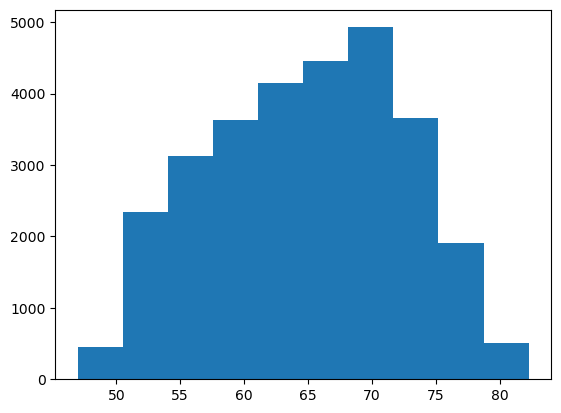

In [104]:
import matplotlib.pyplot as plt
plt.hist(new.age)

Coronary_Artery_Disease
(28212, 74)


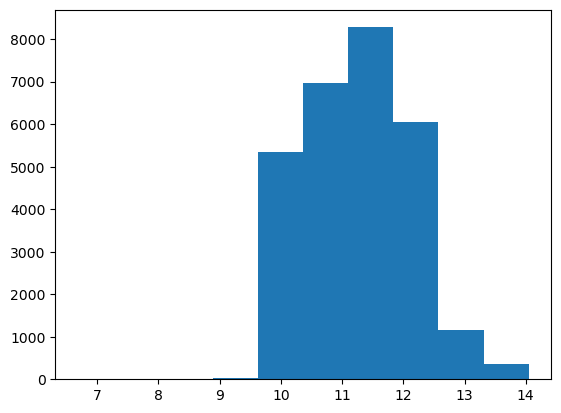

Coronary_Artery_Disease_INTERMEDIATE
(28212, 74)


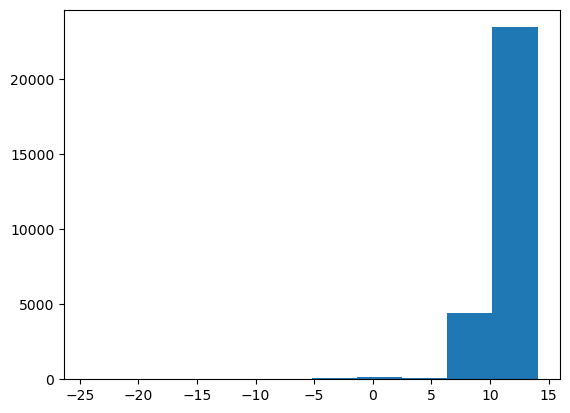

Coronary_Artery_Disease_SOFT
(28212, 74)


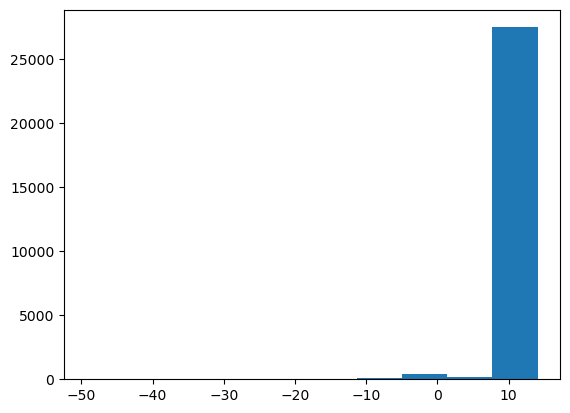

Coronary_Artery_Disease_HARD
(28212, 74)


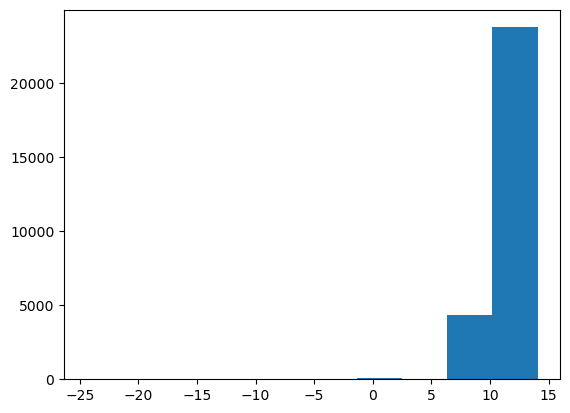

In [96]:
for outcome in ['Coronary_Artery_Disease', 'Coronary_Artery_Disease_INTERMEDIATE', 'Coronary_Artery_Disease_SOFT', 'Coronary_Artery_Disease_HARD']:
    print(outcome)
    new_df = new[new['FollowUp_Coronary_Artery_Disease']>new['time_to_mri_acquisition']/365.25]
    print(new_df.shape)
    fig = plt.hist(new_df['FollowUp_'+outcome])
    plt.show()